# 04 - Train the coffee leaf classifier

First, simple version:
- MobileNetV3-Small (ImageNet-pretrained, `timm`), new 5-class head, whole network fine-tuned
- 256 px input, scenario augmentation on training images, clean `eval_view` on validation images
- class-weighted cross-entropy (the classes are imbalanced), AdamW, cosine learning-rate schedule
- validation accuracy and macro-F1 after every epoch

Saved per run:
- `ml/checkpoints/<run>_best.pt`: weights with the best validation macro-F1
- `ml/checkpoints/<run>_last.pt`: weights after the final epoch
- `ml/runs/<run>.csv`: per-epoch metrics

The test split is not touched here; it is reserved for the final evaluation.

In [1]:
import sys
from pathlib import Path

ML = Path.cwd()
while not (ML / "src").exists():
    ML = ML.parent
sys.path.insert(0, str(ML))

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader

from src.config import CLASSES, SPLITS
from src.dataset import MEAN, STD, LeafDataset
from src.model import build_model, load_checkpoint

CHECKPOINTS = ML / "checkpoints"
RUNS = ML / "runs"
CHECKPOINTS.mkdir(exist_ok=True)
RUNS.mkdir(exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(42)
print("device:", device)

device: mps


In [2]:
config = {
    "run": "scenario_v1",
    "arch": "mobilenetv3_small_100",
    "aug": "scenario",
    "size": 256,
    "epochs": 20,
    "batch_size": 32,
    "lr": 5e-4,
    "weight_decay": 1e-4,
    "num_workers": 6,
}
config

{'run': 'scenario_v1',
 'arch': 'mobilenetv3_small_100',
 'aug': 'scenario',
 'size': 256,
 'epochs': 20,
 'batch_size': 32,
 'lr': 0.0005,
 'weight_decay': 0.0001,
 'num_workers': 6}

## Data

In [3]:
train_ds = LeafDataset(SPLITS / "train.csv", mode=config["aug"], size=config["size"])
val_ds = LeafDataset(SPLITS / "val.csv", mode="eval", size=config["size"])

loader_kw = dict(num_workers=config["num_workers"], persistent_workers=True)
train_dl = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True, drop_last=True, **loader_kw)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, **loader_kw)

counts = train_ds.df["label"].value_counts().sort_index().values
class_weights = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32)
pd.DataFrame({"train images": counts, "loss weight": class_weights.numpy().round(2)}, index=CLASSES)

,train images,loss weight
healthy,99,1.90
leaf_miner,178,1.06
rust,326,0.58
phoma,242,0.78
cercospora,95,1.98


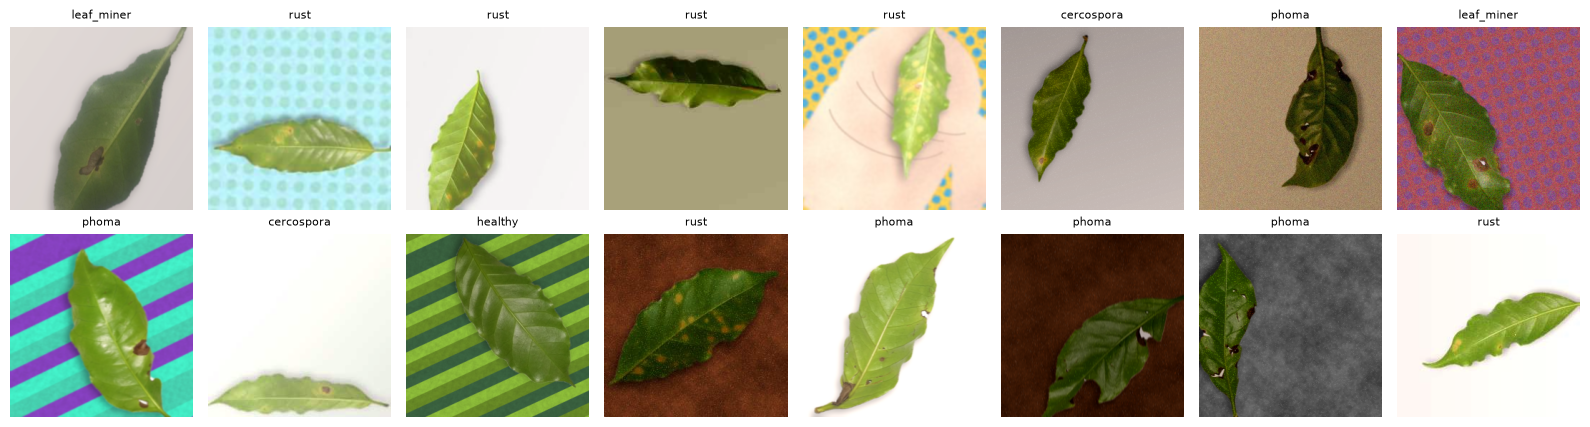

In [4]:
# Sanity check: one training batch exactly as the model sees it (de-normalised).
x, y = next(iter(train_dl))
fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))
for ax, img, label in zip(axes.flat, x, y):
    ax.imshow(np.clip(img.permute(1, 2, 0).numpy() * STD + MEAN, 0, 1))
    ax.set_title(CLASSES[label], fontsize=8)
    ax.axis("off")
plt.tight_layout()

## Model and training loop

In [5]:
model = build_model(config["arch"]).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"] * len(train_dl))
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters")


def train_one_epoch():
    model.train()
    total, n = 0.0, 0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        loss = criterion(model(x), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        total += loss.item() * len(y)
        n += len(y)
    return total / n


@torch.no_grad()
def evaluate(dl):
    model.eval()
    logits, labels = [], []
    for x, y in dl:
        logits.append(model(x.to(device)).cpu())
        labels.append(y)
    logits, labels = torch.cat(logits), torch.cat(labels)
    preds = logits.argmax(1)
    return {
        "loss": criterion(logits.to(device), labels.to(device)).item(),
        "acc": (preds == labels).float().mean().item(),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "logits": logits,
        "labels": labels,
    }


def save(path, epoch, metrics):
    torch.save({
        "model": model.state_dict(),
        "config": config,
        "classes": CLASSES,
        "epoch": epoch,
        "val_acc": metrics["acc"],
        "val_macro_f1": metrics["macro_f1"],
    }, path)

1.52M parameters


In [6]:
run = config["run"]
best_path, last_path = CHECKPOINTS / f"{run}_best.pt", CHECKPOINTS / f"{run}_last.pt"
history, best_f1 = [], -1.0

for epoch in range(1, config["epochs"] + 1):
    t = time.time()
    train_loss = train_one_epoch()
    val = evaluate(val_dl)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val["loss"],
                    "val_acc": val["acc"], "val_macro_f1": val["macro_f1"],
                    "lr": optimizer.param_groups[0]["lr"]})
    pd.DataFrame(history).to_csv(RUNS / f"{run}.csv", index=False)

    marker = ""
    if val["macro_f1"] > best_f1:
        best_f1 = val["macro_f1"]
        save(best_path, epoch, val)
        marker = "  <- best, saved"
    print(f"epoch {epoch:2d}  train loss {train_loss:.3f}  val loss {val['loss']:.3f}  "
          f"val acc {val['acc']:.3f}  val macro-F1 {val['macro_f1']:.3f}  ({time.time() - t:.0f}s){marker}")

save(last_path, epoch, val)
print(f"\nbest val macro-F1 {best_f1:.3f}\nsaved: {best_path.relative_to(ML.parent)}\nsaved: {last_path.relative_to(ML.parent)}")

epoch  1  train loss 3.533  val loss 2.365  val acc 0.448  val macro-F1 0.381  (16s)  <- best, saved


epoch  2  train loss 1.606  val loss 0.876  val acc 0.617  val macro-F1 0.635  (11s)  <- best, saved


epoch  3  train loss 1.208  val loss 0.848  val acc 0.776  val macro-F1 0.740  (11s)  <- best, saved


epoch  4  train loss 1.111  val loss 0.819  val acc 0.682  val macro-F1 0.660  (11s)


epoch  5  train loss 0.949  val loss 0.938  val acc 0.726  val macro-F1 0.684  (12s)


...

epoch 16  train loss 0.509  val loss 0.350  val acc 0.866  val macro-F1 0.845  (13s)


epoch 17  train loss 0.497  val loss 0.349  val acc 0.876  val macro-F1 0.854  (13s)


epoch 18  train loss 0.449  val loss 0.348  val acc 0.866  val macro-F1 0.844  (12s)


epoch 19  train loss 0.475  val loss 0.367  val acc 0.866  val macro-F1 0.844  (13s)


epoch 20  train loss 0.470  val loss 0.361  val acc 0.866  val macro-F1 0.844  (13s)

best val macro-F1 0.870
saved: ml/checkpoints/scenario_v1_best.pt
saved: ml/checkpoints/scenario_v1_last.pt


## Learning curves

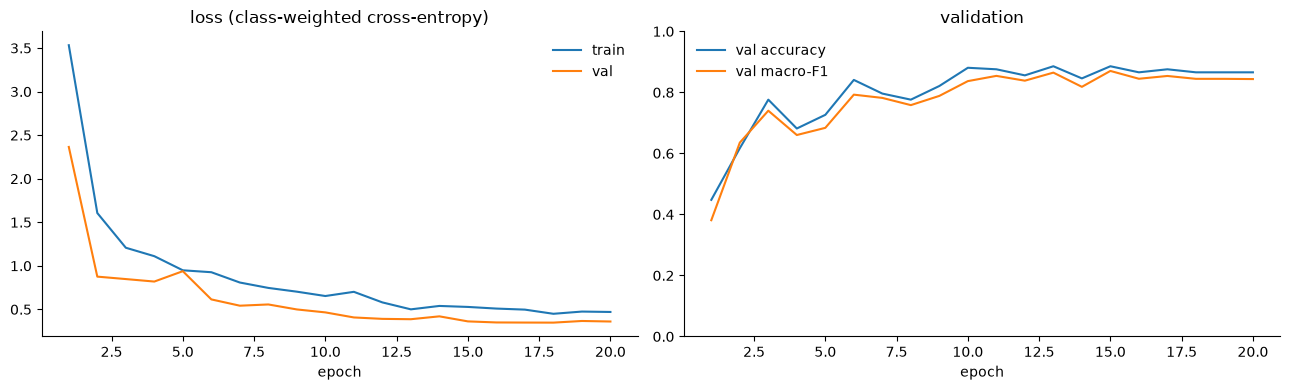

In [7]:
h = pd.read_csv(RUNS / f"{run}.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h["epoch"], h["train_loss"], label="train")
axes[0].plot(h["epoch"], h["val_loss"], label="val")
axes[0].set_title("loss (class-weighted cross-entropy)")
axes[1].plot(h["epoch"], h["val_acc"], label="val accuracy")
axes[1].plot(h["epoch"], h["val_macro_f1"], label="val macro-F1")
axes[1].set_ylim(0, 1)
axes[1].set_title("validation")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## Best checkpoint on the validation set

best epoch 15: val acc 0.886, val macro-F1 0.870

              precision    recall  f1-score   support

     healthy      0.955     1.000     0.977        21
  leaf_miner      0.829     0.763     0.795        38
        rust      0.955     0.913     0.933        69
       phoma      0.923     0.923     0.923        52
  cercospora      0.654     0.810     0.723        21

    accuracy                          0.886       201
   macro avg      0.863     0.882     0.870       201
weighted avg      0.891     0.886     0.887       201



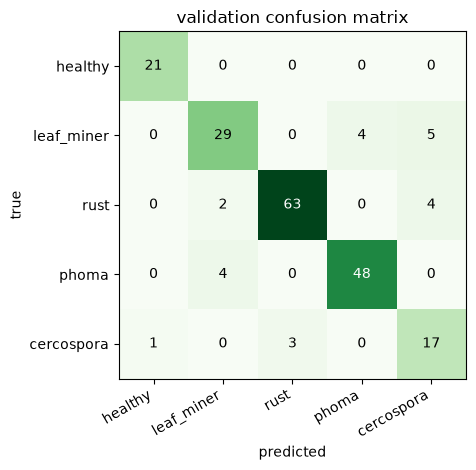

In [8]:
model, ckpt = load_checkpoint(best_path, device)
val = evaluate(val_dl)
preds = val["logits"].argmax(1)
print(f"best epoch {ckpt['epoch']}: val acc {val['acc']:.3f}, val macro-F1 {val['macro_f1']:.3f}\n")
print(classification_report(val["labels"], preds, target_names=CLASSES, digits=3))

cm = confusion_matrix(val["labels"], preds, labels=range(len(CLASSES)))
fig, ax = plt.subplots(figsize=(5.5, 4.8))
ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=30, ha="right")
ax.set_yticks(range(len(CLASSES)), CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("validation confusion matrix")
plt.tight_layout()